In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("/content/placement (2).csv")

In [3]:
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


Text(0, 0.5, 'PACKAGE')

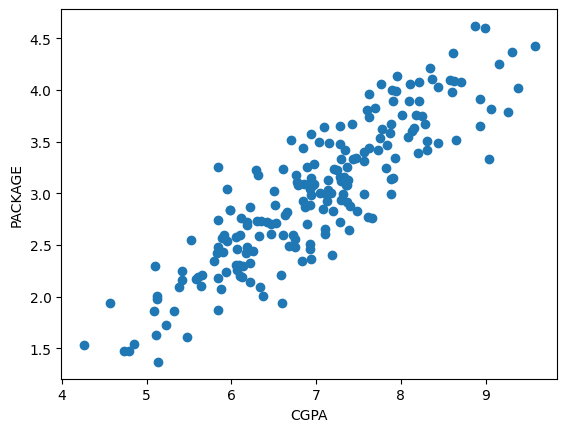

In [4]:
plt.scatter(df['cgpa'] , df['package'])
plt.xlabel('CGPA')
plt.ylabel('PACKAGE')

In [5]:
x = df.iloc[:,0:1]
y = df.iloc[:,1]

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
X_train , X_test , y_train ,y_test = train_test_split(x,y, test_size= 0.2 , random_state=2)

In [8]:
from sklearn.linear_model import LinearRegression

In [9]:
lr = LinearRegression()

In [10]:
lr.fit(X_train , y_train)

LinearRegression()

In [11]:
X_test

,cgpa
112,8.58
29,7.15
182,5.88
199,6.22
193,4.57
85,4.79
10,5.32
54,6.86
115,8.35
35,6.87


In [12]:
y_test

,package
112,4.10
29,3.49
182,2.08
199,2.33
193,1.94
85,1.48
10,1.86
54,3.09
115,4.21
35,2.87


In [13]:
lr.predict(X_test.iloc[0].values.reshape(1,1))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([3.89111601])

Text(0, 0.5, 'Package')

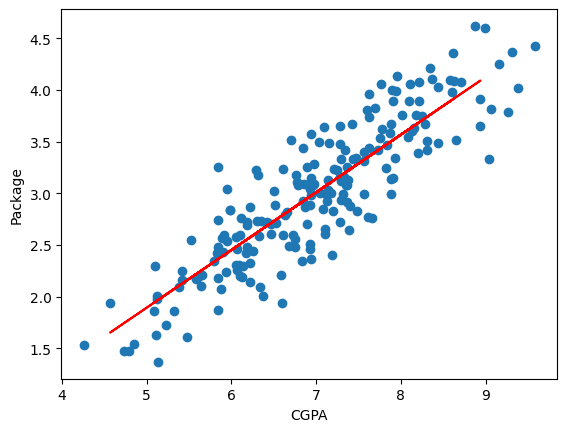

In [14]:
plt.scatter(df['cgpa'] , df['package'])
plt.plot(X_test,lr.predict(X_test) , color = 'red')
plt.xlabel('CGPA')
plt.ylabel('Package')

Text(0, 0.5, 'Package')

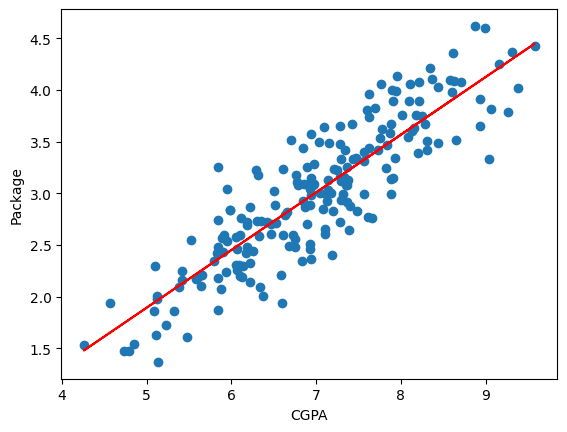

In [15]:
plt.scatter(df['cgpa'] , df['package'])
plt.plot(X_train,lr.predict(X_train) , color = 'red')
plt.xlabel('CGPA')
plt.ylabel('Package')

In [16]:
#the slop of the line fromed due to the linear model
m = lr.coef_
m

array([0.55795197])

In [17]:
#the y intercept of the line formed due to the linear model
b = lr.intercept_

In [18]:
#now how to predict - y = mx+b
y = m*(8.58) + b

In [19]:
# it matches with the above value that we predicted
y

array([3.89111601])

In [20]:
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score

In [22]:
y_pred = lr.predict(X_test)

In [23]:
y_test.values

array([4.1 , 3.49, 2.08, 2.33, 1.94, 1.48, 1.86, 3.09, 4.21, 2.87, 3.65,
       4.  , 2.89, 2.6 , 2.99, 3.25, 1.86, 3.67, 2.37, 3.42, 2.48, 3.65,
       2.6 , 2.83, 4.08, 2.56, 3.58, 3.81, 4.09, 2.01, 3.63, 2.92, 3.51,
       1.94, 2.21, 3.34, 3.34, 3.23, 2.01, 2.61])

In [24]:
print("MAE" , mean_absolute_error(y_test , y_pred))
#this is in the unit of lpa

MAE 0.2884710931878175


In [26]:
print('MSE' , mean_squared_error(y_test , y_pred))
#this is not in lpa , its the square of LPA

MSE 0.12129235313495527


In [27]:
print('RMSE' , np.sqrt(mean_squared_error(y_test , y_pred)))
#this is in lpa , unit of package

RMSE 0.34827051717731616


In [28]:
print('R2_score' , r2_score(y_test , y_pred))

R2_score 0.780730147510384


In [29]:
r2 = r2_score(y_test , y_pred)

In [30]:
#in order t calc the ADJUSTED R2 SCORE
X_test.shape

(40, 1)

In [31]:
1 - ((1-r2)*(40-1)/(40-1-1))

0.7749598882343415

In [32]:
new_df1 = df.copy()
new_df1['random_feature'] = np.random.random(200)

new_df1 = new_df1[['cgpa' , 'random_feature' ,'package']]
new_df1.head()

,cgpa,random_feature,package
0,6.89,0.363010,3.26
1,5.12,0.573817,1.98
2,7.82,0.635556,3.25
3,7.42,0.688702,3.67
4,6.94,0.495025,3.57


In [33]:
X = new_df1.iloc[:,0:2]
y = new_df1.iloc[:,-1]

In [34]:
X_train ,X_test , y_train , y_test = train_test_split(X , y , test_size = 0.2 , random_state = 42)

In [35]:
lr = LinearRegression()

In [36]:
lr.fit(X_train ,y_train)

LinearRegression()

In [37]:
y_pred = lr.predict(X_test)

In [38]:
print('R2 score' , r2_score(y_test ,y_pred))
r2 = r2_score(y_test , y_pred)

R2 score 0.7663316438539742


In [39]:
1 - ((1-r2)*(40-1))/(40-1-2)

0.753700921900135